### Задача 2. Реализация подсчёта треугольников

In [1]:
import numpy as np
import pandas as pd
import os
import time

import graphblas as gb
from graphblas import binary, semiring, dtypes
from graphblas.io import mmread

import matplotlib.pyplot as plt

plt.style.use('bmh')

Везде считаем, что вершины графа занумерованы подряд с нуля.

**1. Используя `python-graphblas` реализовать наивный алгоритм, для матрицы смежности $A$ вычисляющий $A^3$ и возвращающий количество треугольников неориентированного графа.**

- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).

- Функция возвращает число - количество треугольников в графе.

In [2]:
def naiveA3(A):

    A3 = A.mxm(A.mxm(A))
    trace = A3.diag().reduce(gb.agg.sum).value
    
    return int(trace or 0) / 6

**2. Используя `python-graphblas` реализовать наивный алгоритм с маской, для матрицы смежности $A$ вычисляющий $A^2$ и возвращающий количество треугольников неориентированного графа.**

- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).

- Функция возвращает число - количество треугольников в графе.

In [3]:
def naiveMaskA2(A):

    A2 = A.mxm(A)
    mask = A.dup(dtype=dtypes.BOOL)

    return int(A2.dup(mask=mask).reduce_scalar(gb.monoid.plus).value or 0) / 6

**3. Используя `python-graphblas` реализовать Сohen's algorithm, вычисляющий количество треугольников неориентированного графа.**

- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).

- Функция возвращает число - количество треугольников в графе.

In [4]:
def cohen(A):
    
    L = gb.select.tril(A)
    U = gb.select.triu(A)

    mask = A.dup(dtype=dtypes.BOOL)

    return int(L.mxm(U).dup(mask=mask).reduce_scalar(gb.monoid.plus).value or 0) / 2

**4. Используя `python-graphblas` реализовать функцию, вычисляющую для каждой вершины неориентированного графа количество треугольников, в которых она участвует.**

- Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).

- Функция возвращает массив, где для каждой вершины указано, в скольки треугольниках она участвует.

In [5]:
def getTriangles(A):

    mask = A.dup(dtype=dtypes.BOOL)

    C = A.mxm(A).dup(mask=mask)

    row_sum = C.reduce_rowwise(gb.monoid.plus)

    return row_sum.apply(gb.binary.floordiv, right=2)

**5. Добавить тесты для проверки корректности полученных реализаций.**

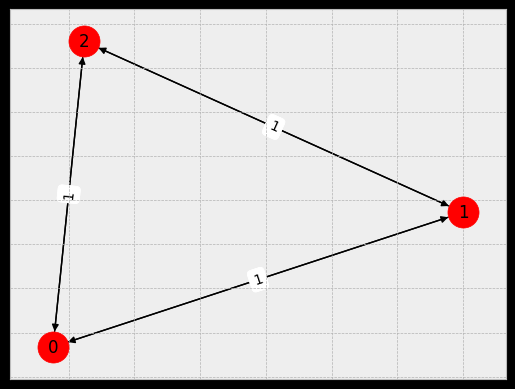

Triangle (K3)        | naiveA3         | 1.0        | OK
                     | naiveMaskA2     | 1.0        | OK
                     | cohen           | 1.0        | OK
                     | getTriangles    | [1, 1, 1]  | OK


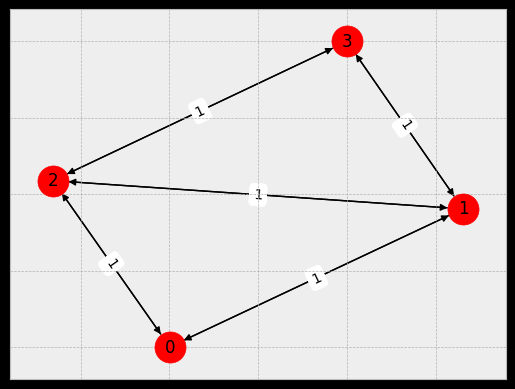

Diamond Graph        | naiveA3         | 2.0        | OK
                     | naiveMaskA2     | 2.0        | OK
                     | cohen           | 2.0        | OK
                     | getTriangles    | [1, 2, 2, 1] | OK


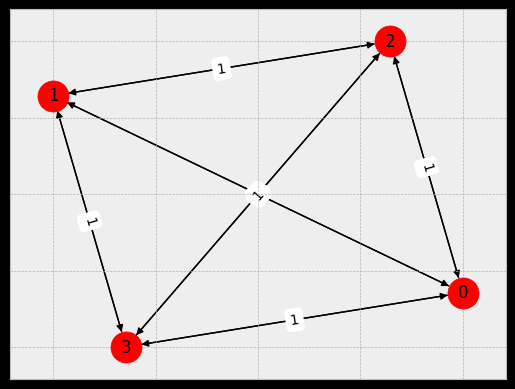

Complete (K4)        | naiveA3         | 4.0        | OK
                     | naiveMaskA2     | 4.0        | OK
                     | cohen           | 4.0        | OK
                     | getTriangles    | [3, 3, 3, 3] | OK


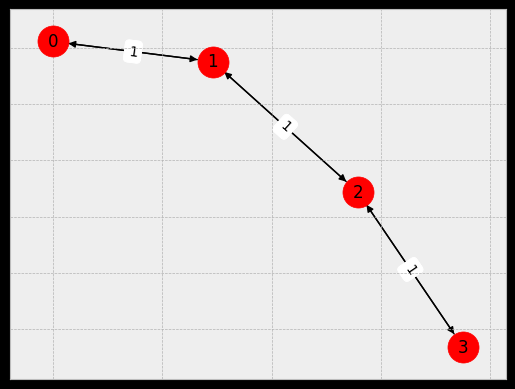

Path (P4)            | naiveA3         | 0.0        | OK
                     | naiveMaskA2     | 0.0        | OK
                     | cohen           | 0.0        | OK
                     | getTriangles    | [0, 0, 0, 0] | OK


In [6]:
def run_tests():
    # 1. Одиночный треугольник (K3)
    K3 = gb.Matrix.from_coo([0, 0, 1, 1, 2, 2], [1, 2, 0, 2, 0, 1], [1]*6, nrows=3, ncols=3)
    
    # 2. Алмаз (Diamond)
    rows_d = [0,0, 1,1,1, 2,2,2, 3,3]
    cols_d = [1,2, 0,2,3, 0,1,3, 1,2]
    diamond = gb.Matrix.from_coo(rows_d, cols_d, [1]*10, nrows=4, ncols=4)

    # 3. Полный граф K4
    rows_k4, cols_k4 = [], []
    for i in range(4):
        for j in range(4):
            if i != j:
                rows_k4.append(i); cols_k4.append(j)
    K4 = gb.Matrix.from_coo(rows_k4, cols_k4, [1]*12, nrows=4, ncols=4)

    # 4. Путь P4
    rows_p = [0, 1, 1, 2, 2, 3]
    cols_p = [1, 0, 2, 1, 3, 2]
    P4 = gb.Matrix.from_coo(rows_p, cols_p, [1]*6, nrows=4, ncols=4)

    test_cases = [
        {"name": "Triangle (K3)", "graph": K3, "expected_total": 1, "expected_nodes": [1, 1, 1]},
        {"name": "Diamond Graph", "graph": diamond, "expected_total": 2, "expected_nodes": [1, 2, 2, 1]},
        {"name": "Complete (K4)", "graph": K4, "expected_total": 4, "expected_nodes": [3, 3, 3, 3]},
        {"name": "Path (P4)", "graph": P4, "expected_total": 0, "expected_nodes": [0, 0, 0, 0]},
    ]


    for tc in test_cases:
        A = tc['graph']
        gb.viz.draw(A)
        name = tc['name']
        expected = tc['expected_total']
        
        methods = [('naiveA3', naiveA3),
                   ('naiveMaskA2', naiveMaskA2),
                   ('cohen', cohen)]
        
        first_row = True

        for m_name, m_func in methods:
            actual = m_func(A)
            status = 'OK' if actual == expected else 'FAIL'
            
            prefix = f'{name:<20}' if first_row else ' ' * 20
            print(f'{prefix} | {m_name:<15} | {actual:<10} | {status}')
            first_row = False
            
        # Проверка по вершинам (getTriangles)
        res_nodes = getTriangles(A)
        actual_nodes = [int(res_nodes.get(i, default=0)) for i in range(A.nrows)]
        node_status = 'OK' if actual_nodes == tc['expected_nodes'] else 'FAIL'
        print(f"{' ' * 20} | {'getTriangles':<15} | {str(actual_nodes):<10} | {node_status}")


run_tests()

**6. Скачать 10 графов в формате `Matrix Market` с сайта SuiteSparse Matrix Collection и оценить время работы всех полученных реализаций. Сделать выводы.**

- В качестве фильтров для поиска графов на сайте использовать следующие значения: `Rutherford-Boeing Type` = `Binary`, `Special Structure` = `Symmetric`, `Nonzeros.Min` = 10000.

In [7]:
os.listdir('./data')

['bcspwr10.mtx',
 'bcsstk30.mtx',
 'bcsstk33.mtx',
 'dwt_992.mtx',
 'gearbox.mtx',
 'M6.mtx',
 'pct20stif.mtx',
 'pli.mtx',
 'troll.mtx']

In [8]:
def benchmark():
    results = []
    
    for i in os.listdir('./data'):
        A = mmread('./data/' + i)
        
        methods = [
            ("naiveA3", naiveA3),
            ("naiveMaskA2", naiveMaskA2),
            ("cohen", cohen),
            ("getTriangles", getTriangles)
        ]
        
        row = {"Matrix": i, "N": A.nrows, "NNZ": A.nvals}
        
        for m_name, m_func in methods:
            start = time.perf_counter()
            try:
                m_func(A)
                end = time.perf_counter()
                row[m_name] = end - start
            except Exception as e:
                row[m_name] = "Error/Timeout"
        
        results.append(row)
    
    return results

df = pd.DataFrame(benchmark())

In [9]:
df.sort_values('N')

,Matrix,N,NNZ,naiveA3,naiveMaskA2,cohen,getTriangles
3,dwt_992.mtx,992,16744,0.003246,0.000971,0.000738,0.001043
0,bcspwr10.mtx,5300,21842,0.006821,0.002237,0.000981,0.001748
2,bcsstk33.mtx,8738,591904,0.047782,0.013100,0.011143,0.015289
7,pli.mtx,22695,1350309,0.158624,0.021019,0.013774,0.021607
1,bcsstk30.mtx,28924,2043492,0.149662,0.029019,0.020222,0.035357
6,pct20stif.mtx,52329,2698463,0.140566,0.034290,0.024278,0.037162
4,gearbox.mtx,153746,9080404,0.469050,0.100197,0.060159,0.108104
8,troll.mtx,213453,11985111,0.573134,0.119096,0.081435,0.131106
5,M6.mtx,3501776,21003872,1.468091,0.421075,0.240039,0.437455


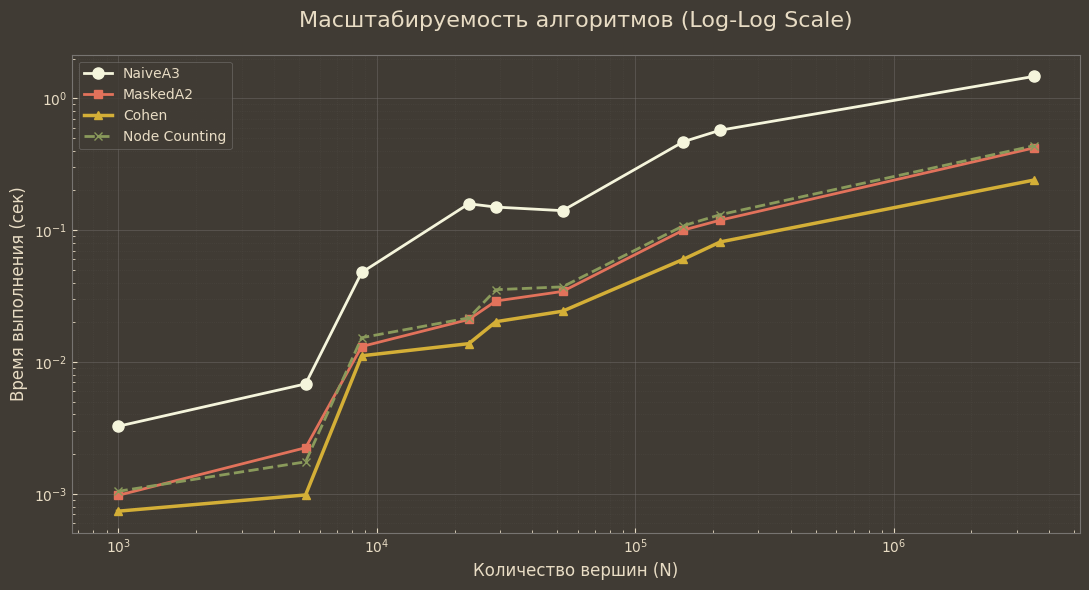

In [10]:
BG_COLOR = "#403B34"      
GRID_COLOR = "#777471"   
TEXT_COLOR = "#E8DCC4"   

COLORS = {
    "cohen": "#D4AF37",        
    "naiveMaskA2": "#E2725B",  
    "getTriangles": "#8A9A5B",  
    "naiveA3": "#F5F5DC"        
}

def plot_benchmark(df):
    import matplotlib.ticker as ticker

    df = df.sort_values('N')
    
    fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    ax.loglog(df['N'], df['naiveA3'], marker='o', label='NaiveA3', color=COLORS["naiveA3"], linewidth=2, markersize=8)
    ax.loglog(df['N'], df['naiveMaskA2'], marker='s', label='MaskedA2', color=COLORS["naiveMaskA2"], linewidth=2)
    ax.loglog(df['N'], df['cohen'], marker='^', label='Cohen', color=COLORS["cohen"], linewidth=2.5)
    ax.loglog(df['N'], df['getTriangles'], marker='x', linestyle='--', label='Node Counting', color=COLORS["getTriangles"])

    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10.0))
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10.0))

    ax.grid(True, which="major", ls="-", color=GRID_COLOR, alpha=0.6)
    ax.grid(True, which="minor", ls=":", color=GRID_COLOR, alpha=0.2)

    ax.set_title('Масштабируемость алгоритмов (Log-Log Scale)', color=TEXT_COLOR, fontsize=16, pad=20)
    ax.set_xlabel('Количество вершин (N)', color=TEXT_COLOR, fontsize=12)
    ax.set_ylabel('Время выполнения (сек)', color=TEXT_COLOR, fontsize=12)
    
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COLOR)

    leg = ax.legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR, fontsize=10, loc='upper left')
    for text in leg.get_texts():
        text.set_color(TEXT_COLOR)

    ax.tick_params(colors=TEXT_COLOR, which='both', labelsize=10)
    
    plt.tight_layout()
    plt.show()

plot_benchmark(df)